# Machine Learning Capstone Project — Regression

## Predicting Superconducting Critical Temperature

### 1. Project Overview

This notebook implements the complete Regression track of the Machine Learning Capstone Project.

The objective is to develop and compare multiple machine learning regression algorithms for predicting the **critical temperature (`critical_temp`)** of superconducting materials using their material-property features.

### Dataset

The dataset used for this regression task is the **Superconductivity Dataset**.

- Target variable: `critical_temp`
- Problem type: Regression
- Input: Material-property features
- Output: Predicted critical temperature
- Link: https://www.kaggle.com/datasets/munumbutt/superconductor-dataset

### Required Regression Algorithms

The following ten regression algorithms will be implemented and compared:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor (KNN)

### Evaluation Metrics

The models will be evaluated using:

- R² Score
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

The two best-performing models will additionally be evaluated using **5-fold cross-validation**.

### Workflow

The notebook follows the complete machine learning pipeline:

**Data Loading → Dataset Audit → EDA → Data Cleaning → Feature Engineering → Train/Test Split → Feature Scaling → Model Training → Evaluation → Hyperparameter Tuning → Cross-Validation → Best Model Analysis → Visualization → Conclusion**

A fixed random state of 42 will be used wherever applicable to ensure reproducibility.

## 2. Import Required Libraries

In this section, we import the Python libraries required for data manipulation, visualization, preprocessing, model development, hyperparameter tuning, and model evaluation.

The main libraries used are:

- **Pandas** and **NumPy** for data handling and numerical operations
- **Matplotlib** and **Seaborn** for data visualization
- **Scikit-learn** for preprocessing, regression algorithms, model selection, and evaluation metrics

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Regression algorithms
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Model evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Model selection and tuning
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Superconductivity Dataset

The Superconductivity Dataset is loaded into a Pandas DataFrame for further analysis.

For the regression task, the target variable is:

**`critical_temp`**

The remaining columns are considered candidate input features for predicting the critical temperature.

The dataset is loaded before performing any cleaning or preprocessing so that the original data can first be audited and understood.

In [2]:
# Load the Superconductivity dataset
df = pd.read_csv("../data/superconductivity/train.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Initial Dataset Preview

Before performing detailed analysis, we inspect the first and last few records of the dataset.

This helps us understand the structure of the data, identify the available features, and verify that the dataset has been loaded correctly.

In [3]:
# Display the first five rows
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [4]:
# Display the last five rows
df.tail()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
21258,4,106.957877,53.095769,82.515384,43.135565,1.177145,1.254119,146.88130,15.504479,65.764081,...,3.555556,3.223710,3.519911,1.377820,0.913658,1,2.168889,0.433013,0.496904,2.44
21259,5,92.266740,49.021367,64.812662,32.867748,1.323287,1.571630,188.38390,7.353333,69.232655,...,2.047619,2.168944,2.038991,1.594167,1.337246,1,0.904762,0.400000,0.212959,122.10
21260,2,99.663190,95.609104,99.433882,95.464320,0.690847,0.530198,13.51362,53.041104,6.756810,...,4.800000,4.472136,4.781762,0.686962,0.450561,1,3.200000,0.500000,0.400000,1.98
21261,2,99.663190,97.095602,99.433882,96.901083,0.690847,0.640883,13.51362,31.115202,6.756810,...,4.690000,4.472136,4.665819,0.686962,0.577601,1,2.210000,0.500000,0.462493,1.84
21262,3,87.468333,86.858500,82.555758,80.458722,1.041270,0.895229,71.75500,43.144000,29.905282,...,4.500000,4.762203,4.242641,1.054920,0.970116,3,1.800000,1.414214,1.500000,12.80


### 4.1 Dataset Dimensions

The shape of the dataset is examined to determine the number of observations and features available for the regression task.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 21263
Number of columns: 82


### 4.2 Dataset Information

The `info()` method is used to inspect:

- Number of observations
- Feature names
- Data types
- Non-null values

This provides an initial understanding of the dataset structure and helps identify potential data-quality issues.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie                 

### 4.3 Missing Value Analysis

Missing values can affect model training and therefore need to be identified before preprocessing.

We calculate the number of missing values in each column and the total number of missing values in the dataset.

In [7]:
# Missing values per column
missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:


Series([], dtype: int64)


Total missing values: 0


### Inference

The missing-value analysis shows that the dataset does not contain missing values in the available variables.

Therefore, no missing-value imputation is required for the current dataset. The dataset can proceed to the subsequent cleaning and exploratory analysis stages without introducing estimated values for missing observations.

### 4.4 Duplicate Record Analysis

Duplicate observations can introduce bias during model training. Therefore, duplicate rows are identified before deciding whether they should be removed during the data-cleaning stage.

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 66


### Inference

The duplicate-row analysis identifies the number of observations that are completely identical across all available columns.

Duplicate rows are not treated as errors solely because their values are repeated. They will be examined as complete-record duplicates and handled during the data-cleaning stage if they represent redundant observations.

Repeated values within individual feature columns are not considered duplicate records because multiple superconducting materials can legitimately have the same value for a particular property.

### 4.5 Statistical Summary

Descriptive statistics are calculated for the numerical variables to understand their central tendency, spread, and range.

This includes:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

The summary will also help identify features that may have very different scales or potential extreme values.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_elements,21263.0,4.115224,1.439295,1.000000,3.000000,4.000000,5.000000,9.0000
mean_atomic_mass,21263.0,87.557631,29.676497,6.941000,72.458076,84.922750,100.404410,208.9804
wtd_mean_atomic_mass,21263.0,72.988310,33.490406,6.423452,52.143839,60.696571,86.103540,208.9804
gmean_atomic_mass,21263.0,71.290627,31.030272,5.320573,58.041225,66.361592,78.116681,208.9804
wtd_gmean_atomic_mass,21263.0,58.539916,36.651067,1.960849,35.248990,39.918385,73.113234,208.9804
...,...,...,...,...,...,...,...,...
range_Valence,21263.0,2.041010,1.242345,0.000000,1.000000,2.000000,3.000000,6.0000
wtd_range_Valence,21263.0,1.483007,0.978176,0.000000,0.921454,1.063077,1.918400,6.9922
std_Valence,21263.0,0.839342,0.484676,0.000000,0.451754,0.800000,1.200000,3.0000
wtd_std_Valence,21263.0,0.673987,0.455580,0.000000,0.306892,0.500000,1.020436,3.0000


### Inference

The descriptive statistics show considerable variation among the numerical material-property features. The features have different minimum and maximum values as well as different means and standard deviations.

This indicates that the predictors are measured on different numerical scales. Such differences are important for regression algorithms that depend on feature magnitude, including Ridge, Lasso, ElasticNet, SVR, and KNN.

The minimum and maximum values will also be considered during the subsequent outlier analysis before deciding whether any observations require treatment.

## 5. Target Variable Analysis

The target variable for this regression problem is `critical_temp`.

Before training the models, we examine its descriptive statistics and distribution to understand the range and overall behaviour of the prediction target.

In [10]:
print("Target variable: critical_temp")
print()

df["critical_temp"].describe()

Target variable: critical_temp



count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

### Inference

The descriptive statistics for `critical_temp` show the central tendency and variability of the target variable, including its mean, standard deviation, minimum, maximum, and quartile values.

The difference between the lower and upper values indicates that the dataset contains superconducting materials with substantially different critical temperatures. This variation provides sufficient target variability for evaluating regression models.

The extreme values will be examined further during outlier analysis rather than being removed automatically.

### 5.1 Distribution of Critical Temperature

The distribution of `critical_temp` is visualized using a histogram with a kernel density estimate.

This visualization helps identify the general shape of the target distribution and whether the values appear concentrated in particular ranges.

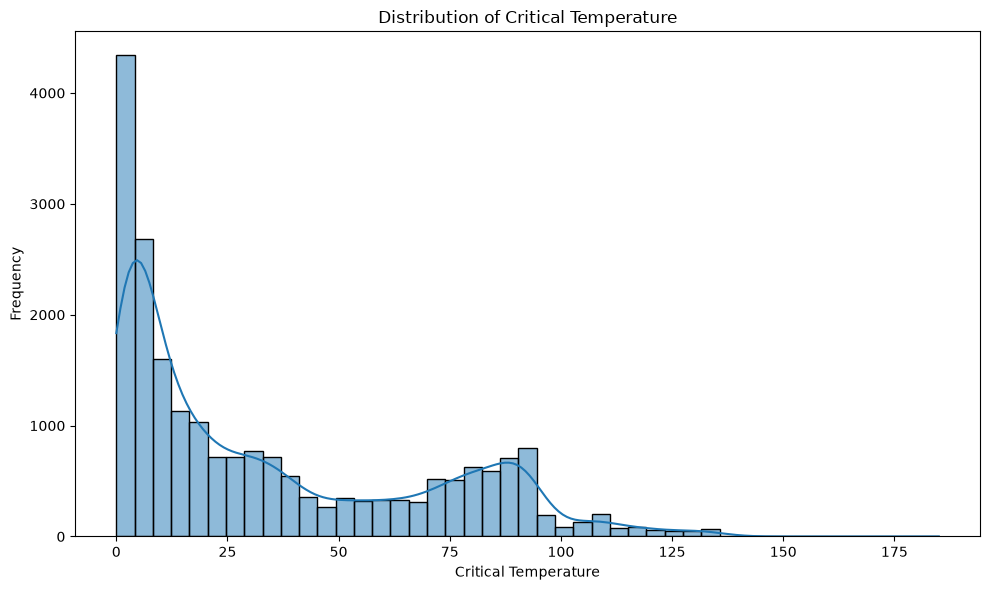

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="critical_temp",
    kde=True
)

plt.title("Distribution of Critical Temperature")
plt.xlabel("Critical Temperature")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Inference

The distribution of `critical_temp` provides an overview of how the critical temperatures of the superconducting materials are spread across the dataset.

The distribution indicates that the target values are not concentrated at a single value and show variation across the superconducting materials. The spread of the target variable confirms that the regression problem involves predicting a continuous quantity with different possible critical-temperature values.

The distribution will also be considered during the later outlier analysis to determine whether unusually high or low target values represent genuine observations or potential anomalies.

### 5.2 Overall Dataset Audit — Inference

The initial dataset audit confirms that the Superconductivity dataset is suitable for the regression task. The dataset contains numerical material-property features along with `critical_temp`, which is the target variable to be predicted.

The data types and dataset structure have been examined to ensure that the input variables can be appropriately processed for regression modelling.

The missing-value analysis has been completed and the presence of missing values has been identified. Duplicate rows have also been checked separately because repeated complete records may affect the model if they are retained without justification.

The descriptive statistics show that the input features have different numerical ranges and levels of variation. Therefore, feature scaling will need to be considered during preprocessing, particularly for scale-sensitive regression algorithms.

The target variable `critical_temp` has also been examined through descriptive statistics and its distribution plot. This provides an initial understanding of the prediction target before proceeding to detailed exploratory analysis.

### 5.3 Unique Value Analysis

The number of unique values in each column is examined to understand the variability of the dataset.

A repeated value within a feature does not necessarily represent a duplicate observation. Therefore, unique-value counts are used only to understand feature variability and identify possible constant or near-constant variables.

In [12]:
unique_counts = df.nunique().sort_values()

unique_counts

range_Valence                  7
number_of_elements             9
mean_Valence                  63
std_Valence                  125
range_atomic_radius          195
                           ...  
wtd_entropy_Density        15087
wtd_gmean_fie              15089
wtd_entropy_atomic_mass    15113
wtd_mean_atomic_mass       15164
wtd_gmean_atomic_mass      15165
Length: 82, dtype: int64

### Inference

The unique-value analysis shows the degree of variability present in each feature. Features with a large number of unique values contain substantial variation across observations, while features with relatively few unique values have more limited variation.

Any feature with no variation would provide no useful information for regression and would therefore need to be considered during preprocessing.

### 5.4 Constant Feature Analysis

A constant feature contains the same value for every observation and therefore cannot provide useful predictive information.

Constant features are identified before proceeding to model development.

In [13]:
constant_features = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))

if constant_features:
    print("Constant features:")
    print(constant_features)
else:
    print("No constant features found.")

Number of constant features: 0
No constant features found.


### Inference

The constant-feature analysis is used to verify whether any predictor remains unchanged across all observations. Constant predictors do not contribute useful information to a regression model and would be removed during preprocessing if present.

## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics and relationships present in the Superconductivity dataset before applying preprocessing and machine learning algorithms.

The EDA focuses on:

1. Distribution of the input features
2. Relationships among numerical features
3. Relationship between features and the target variable
4. Identification of patterns, skewness, and potential anomalies
5. Identification of features that may be useful for predicting `critical_temp`

The observations obtained from EDA will be used to guide the subsequent data-cleaning and feature-engineering stages.

### 6.1 Distribution of Input Features

The distributions of the numerical input features are examined to understand their ranges, spread, central tendency, and possible skewness.

Since the dataset contains a large number of numerical features, the distributions are displayed in multiple organized groups to maintain readability.

In [14]:
# Identify numerical input features
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

# Remove target variable
if "critical_temp" in numerical_features:
    numerical_features.remove("critical_temp")

print("Number of numerical input features:", len(numerical_features))
print("\nInput features:")
print(numerical_features)

Number of numerical input features: 81

Input features:
['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie', 'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie', 'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie', 'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius', 'wtd_gmean_atomic_radius', 'entropy_atomic_radius', 'wtd_entropy_atomic_radius', 'range_atomic_radius', 'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius', 'mean_Density', 'wtd_mean_Density', 'gmean_Density', 'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density', 'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density', 'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity', 'gmean_ElectronAffinity', 'wtd_gmean_ElectronAffinity',

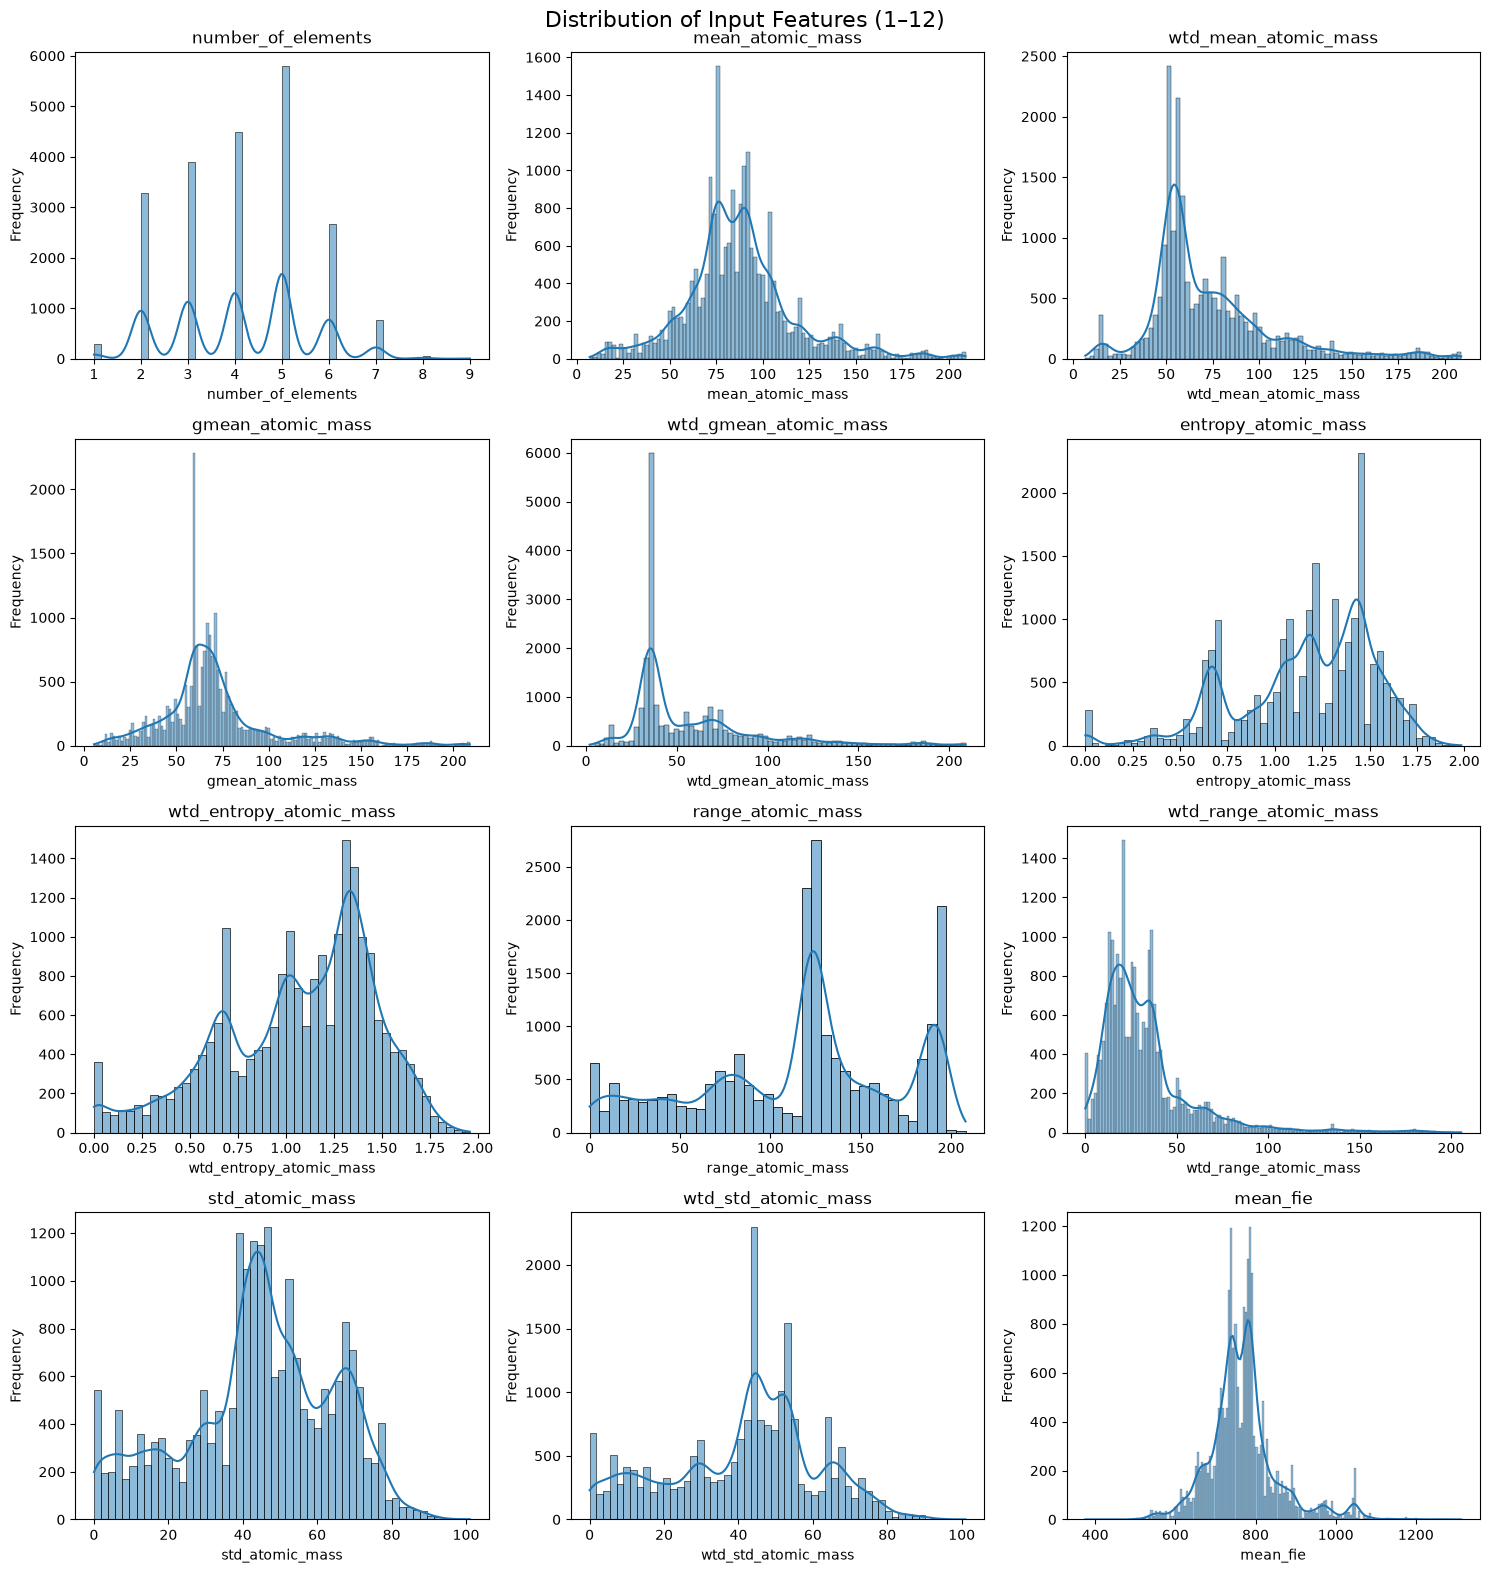

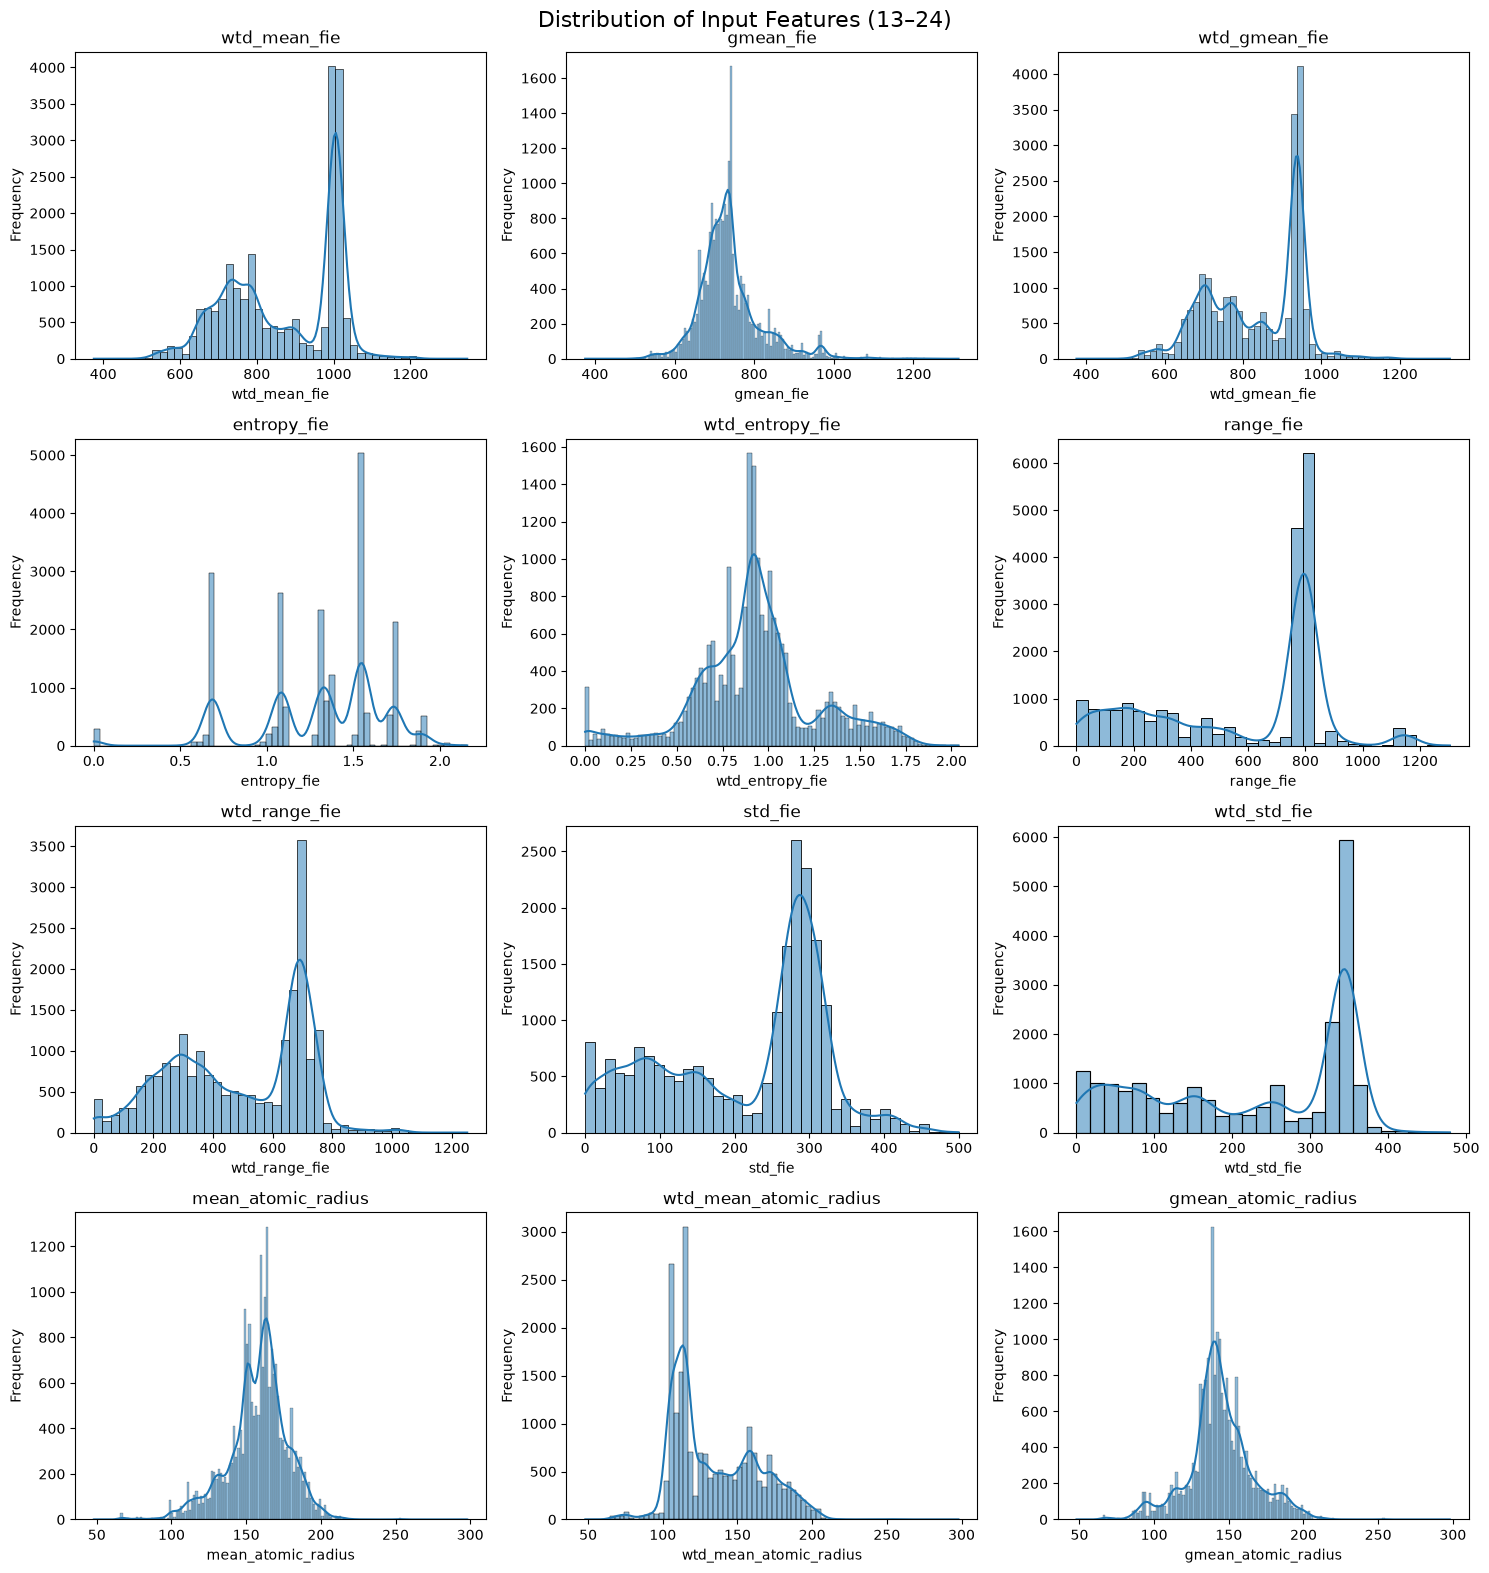

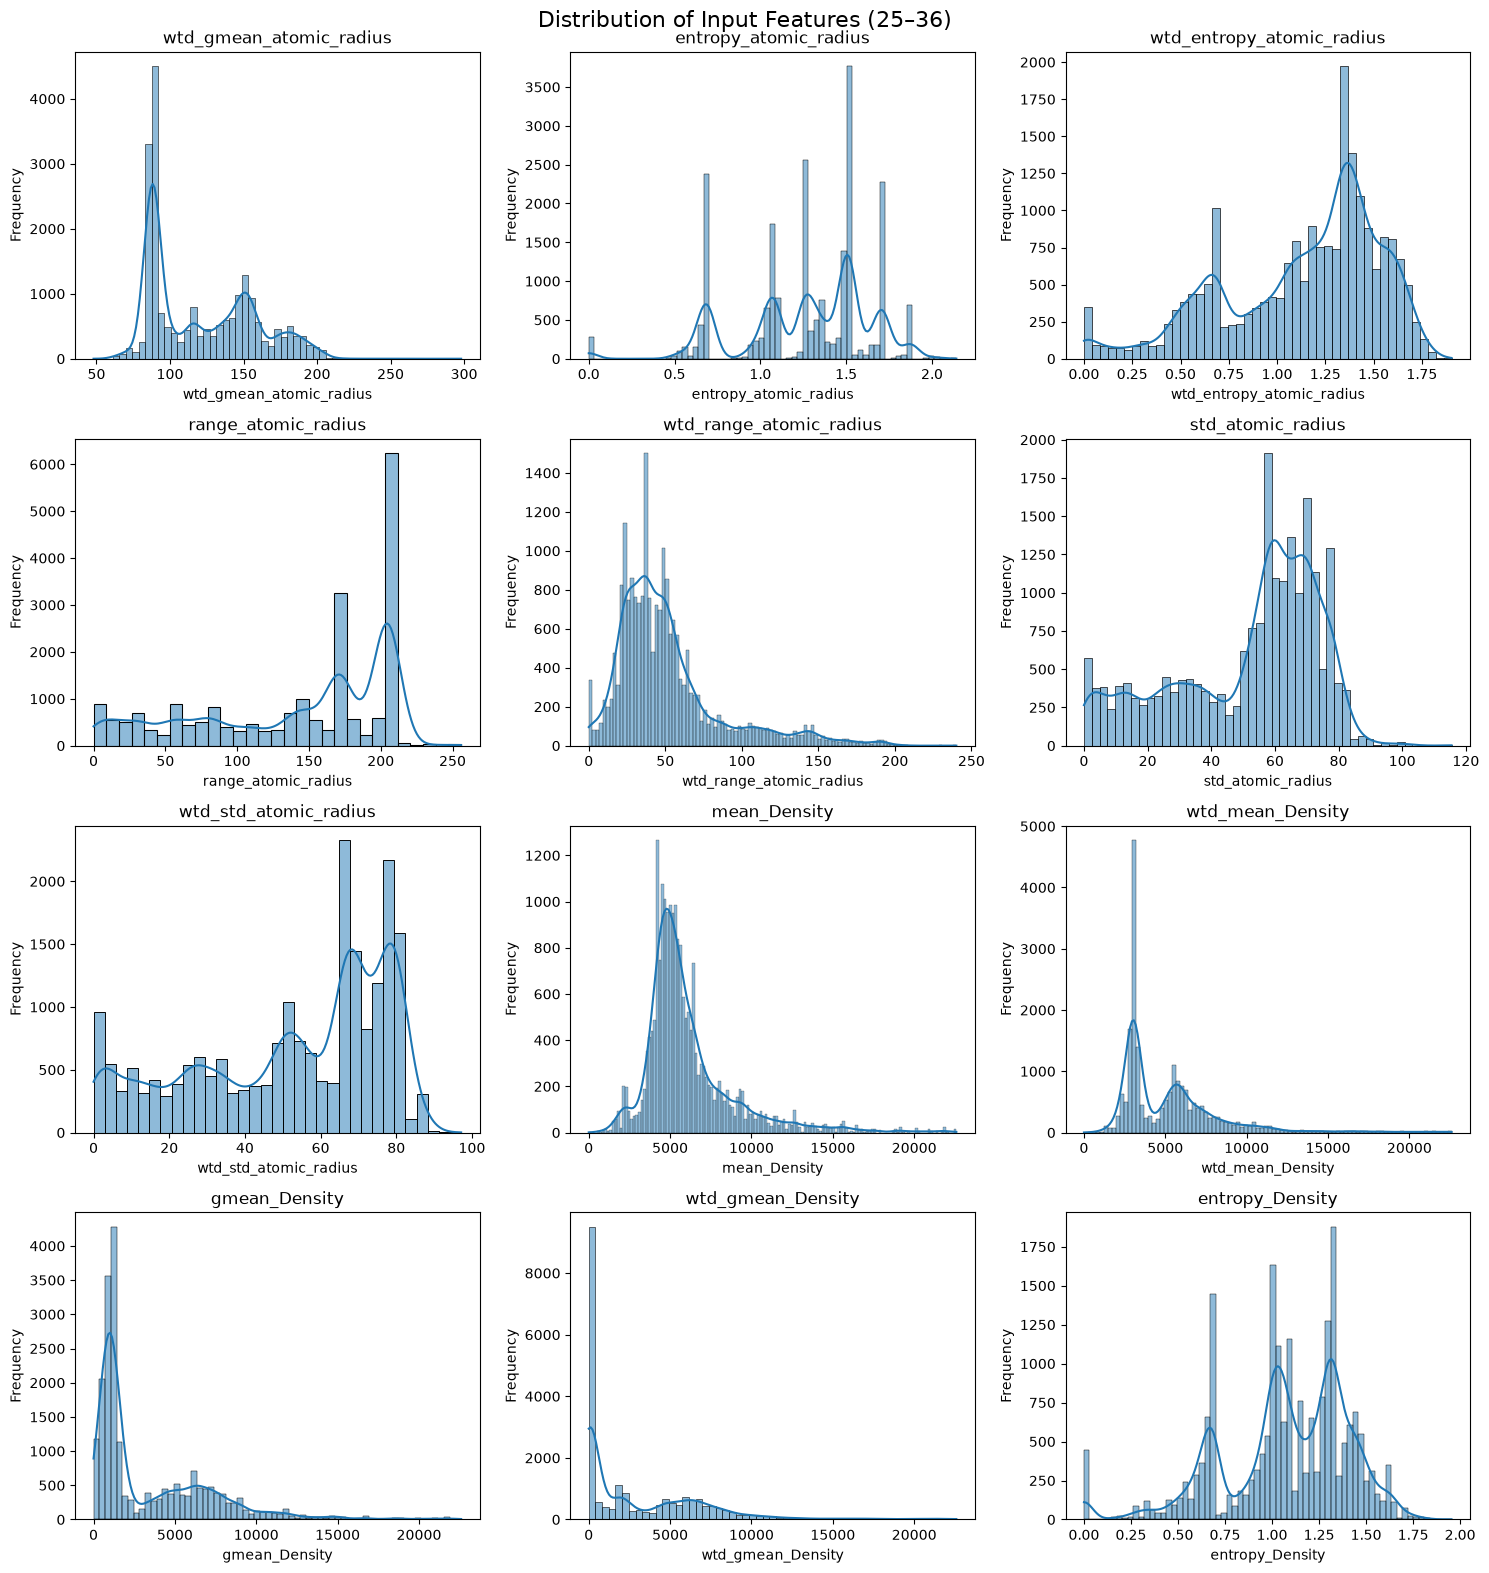

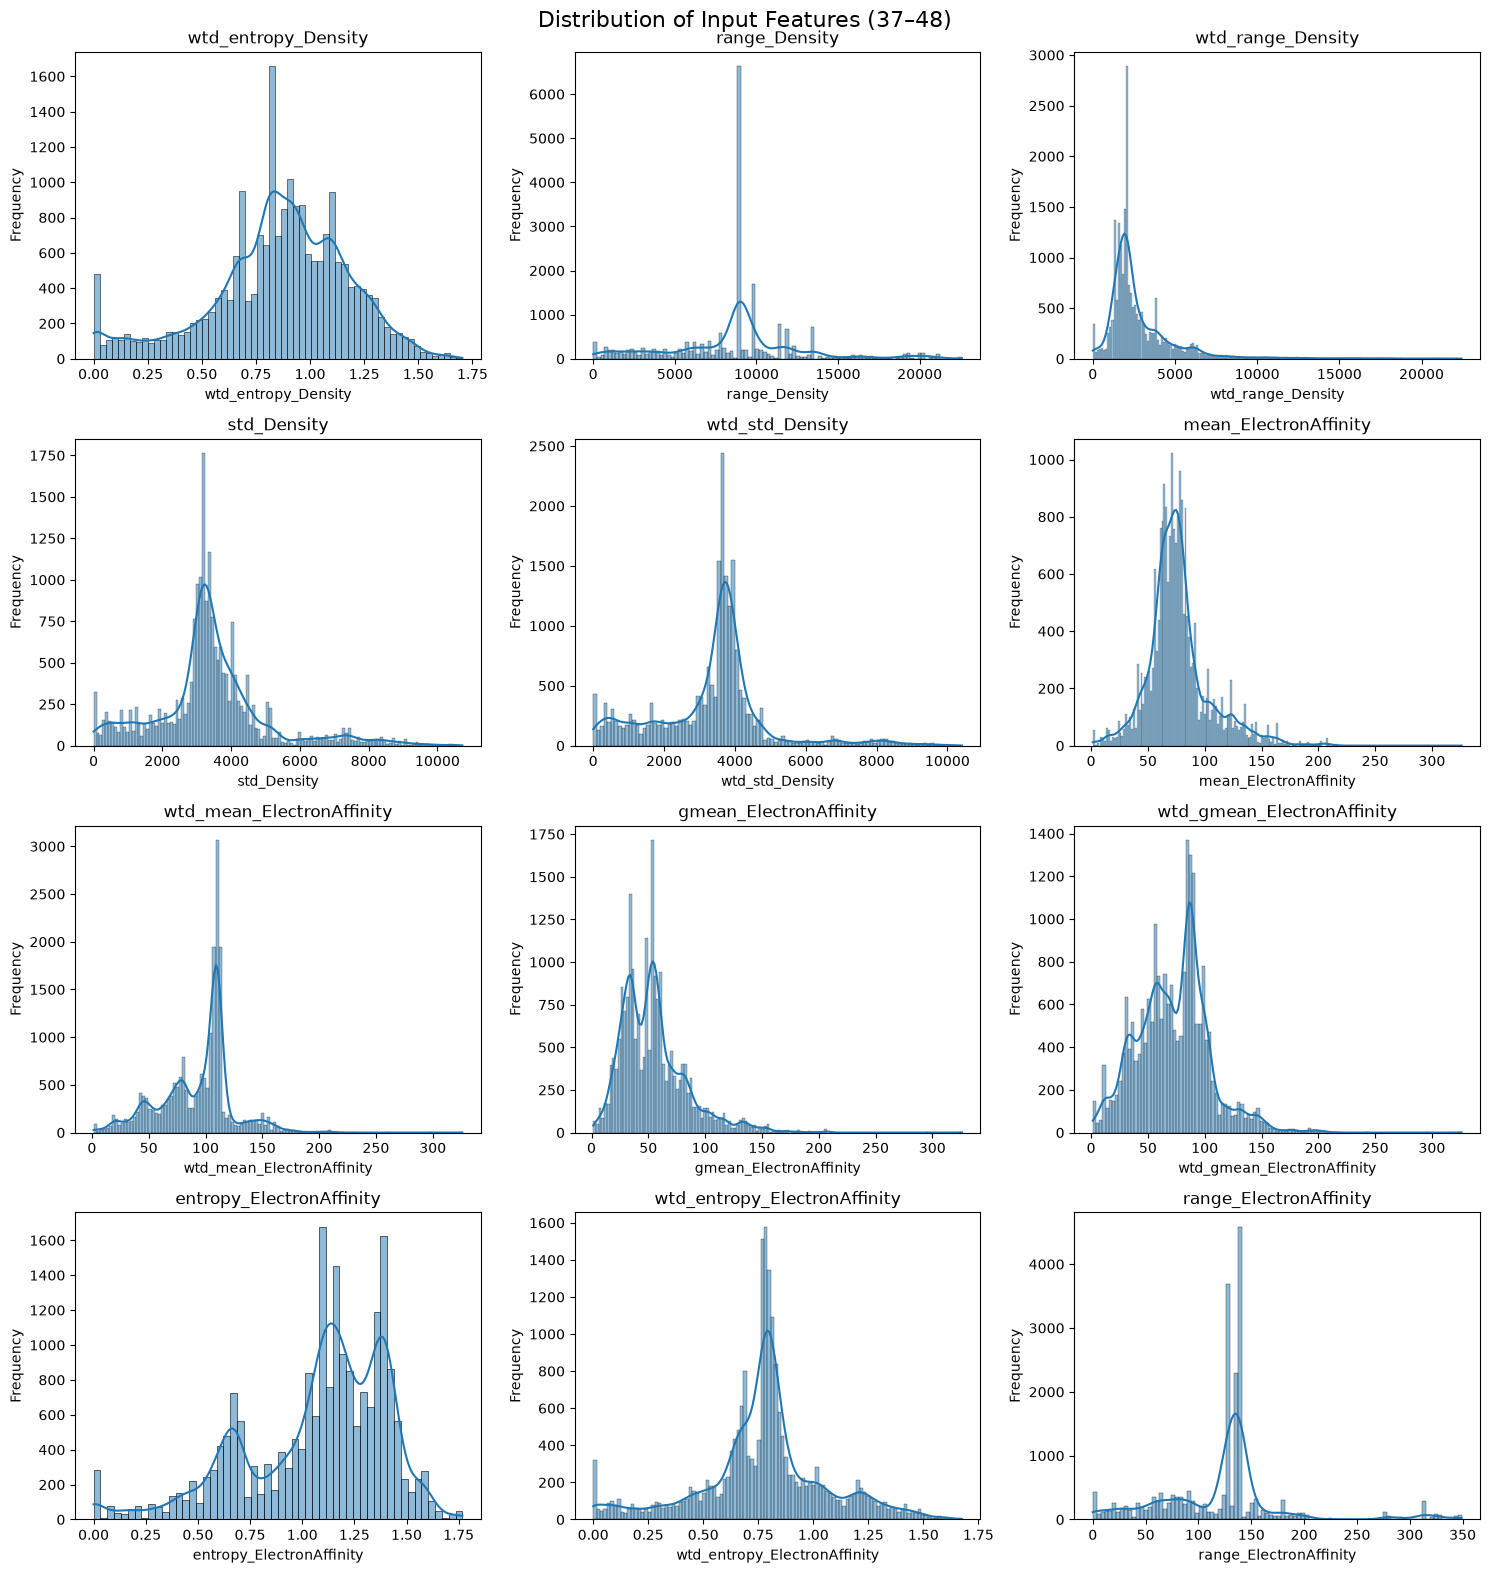

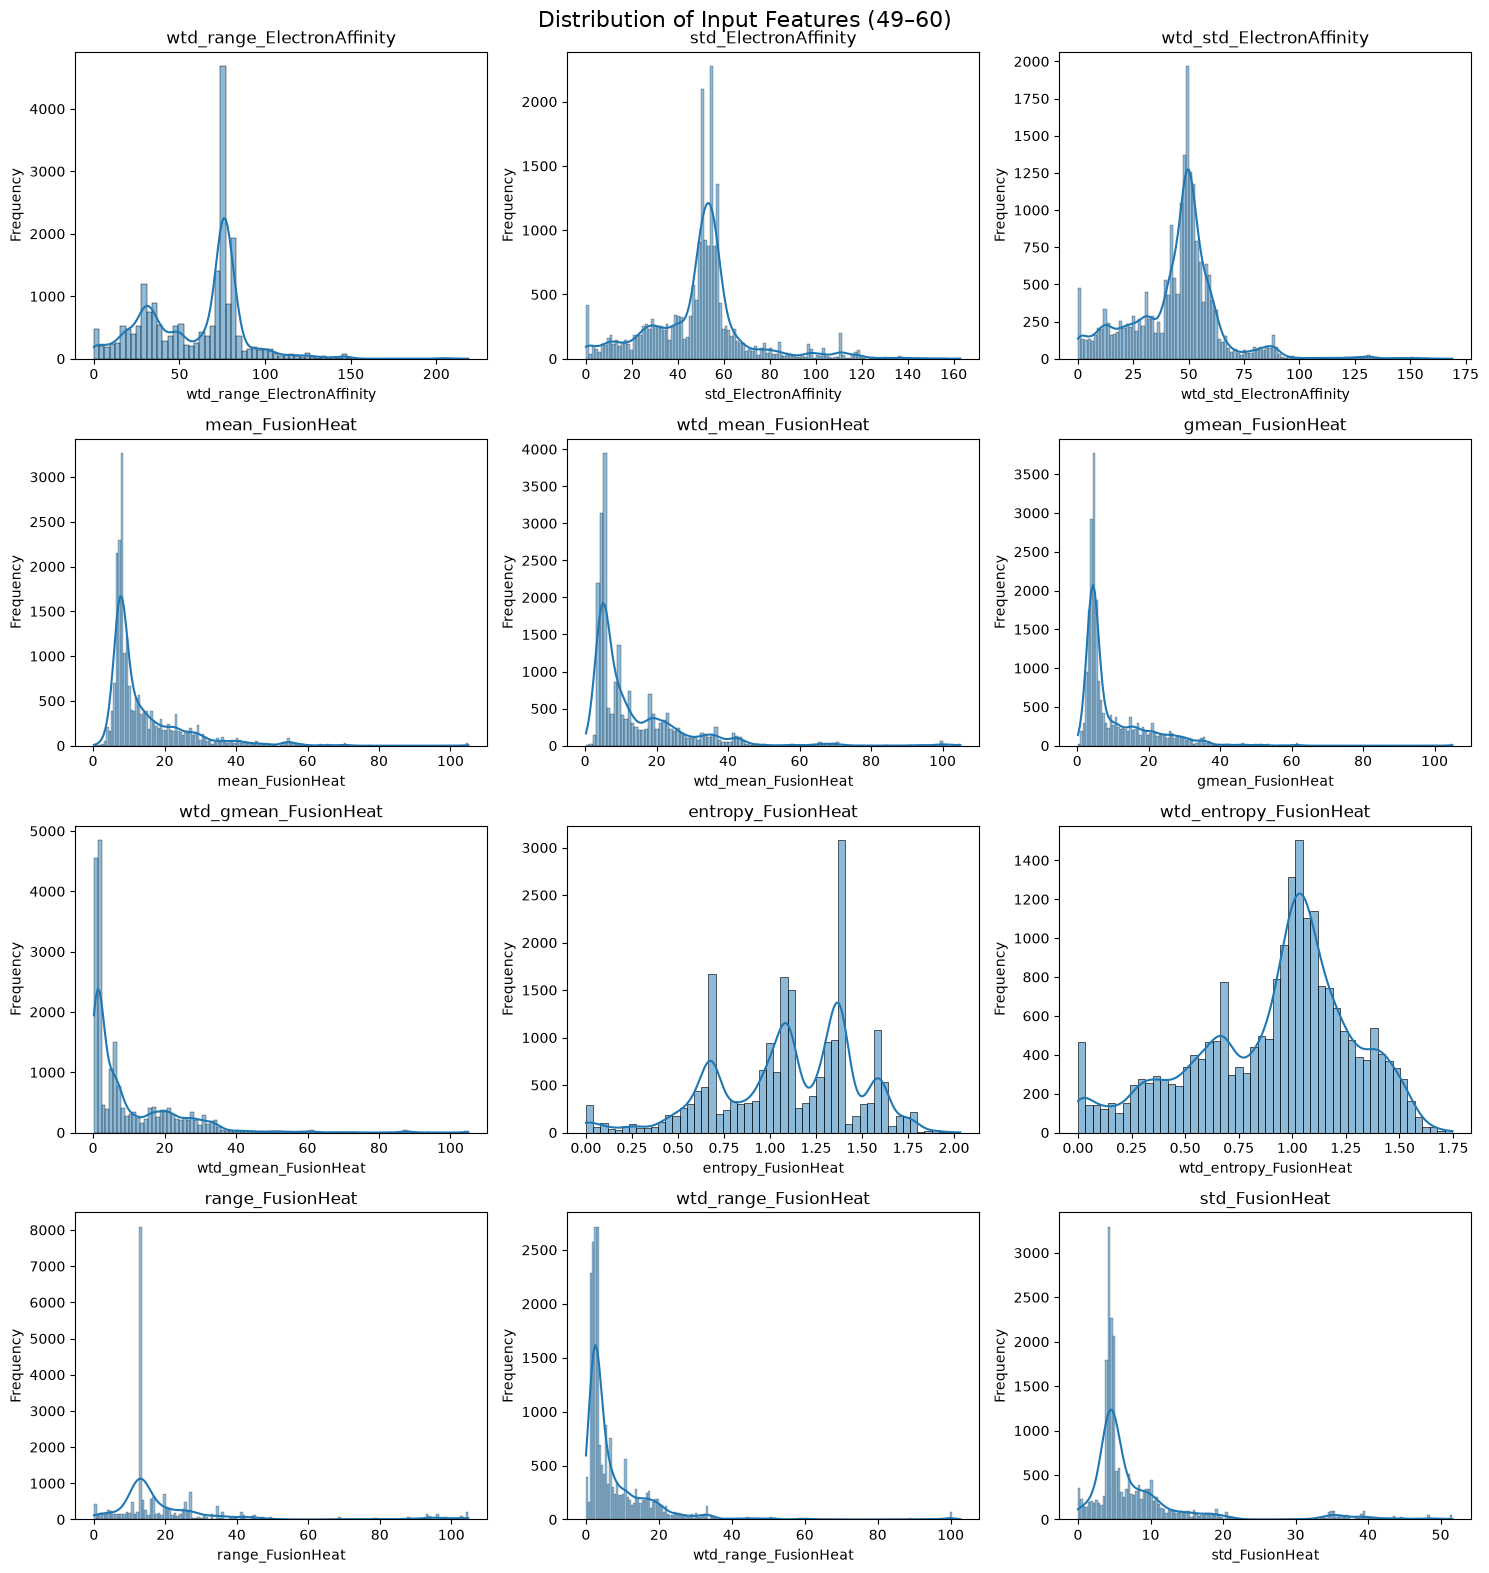

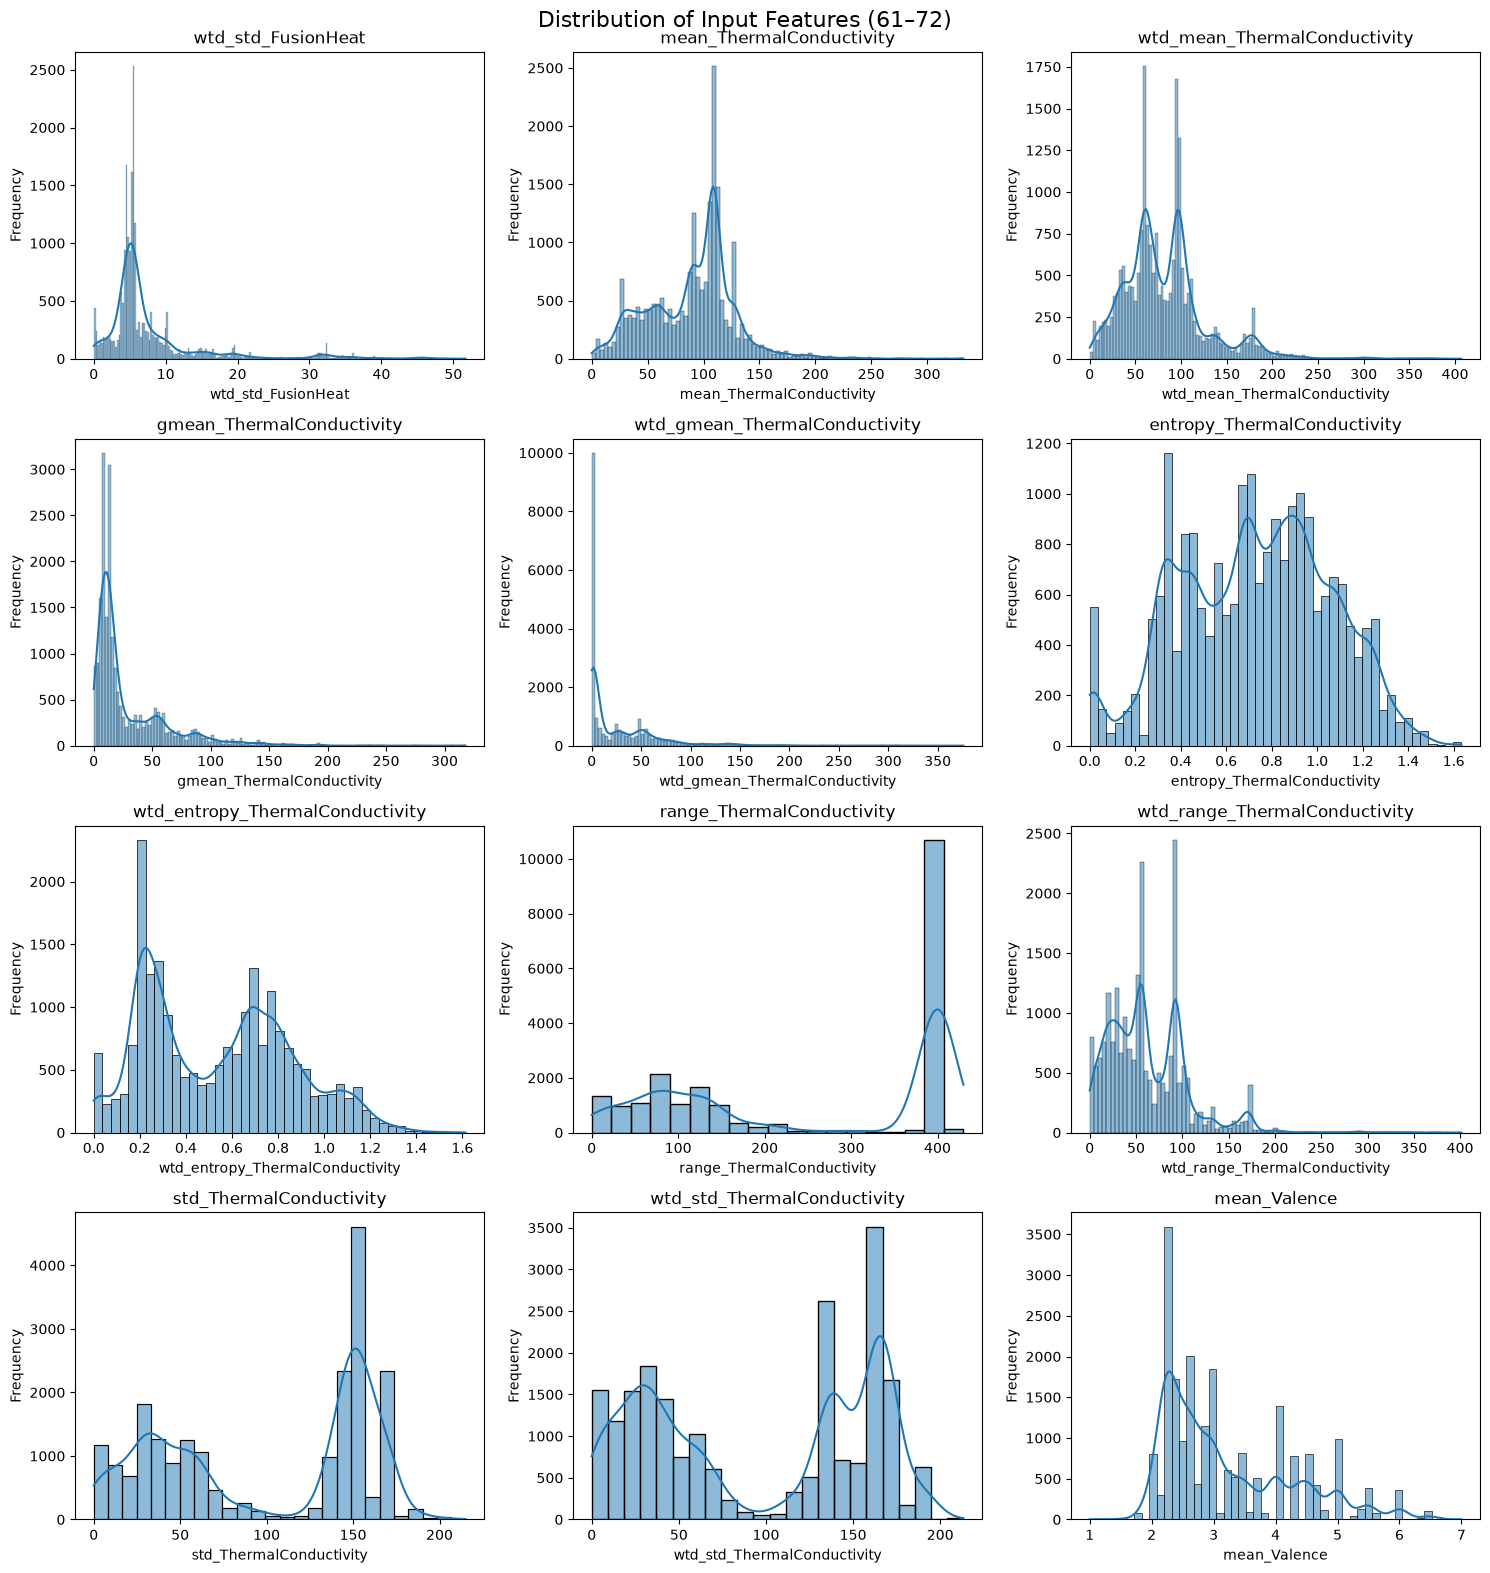

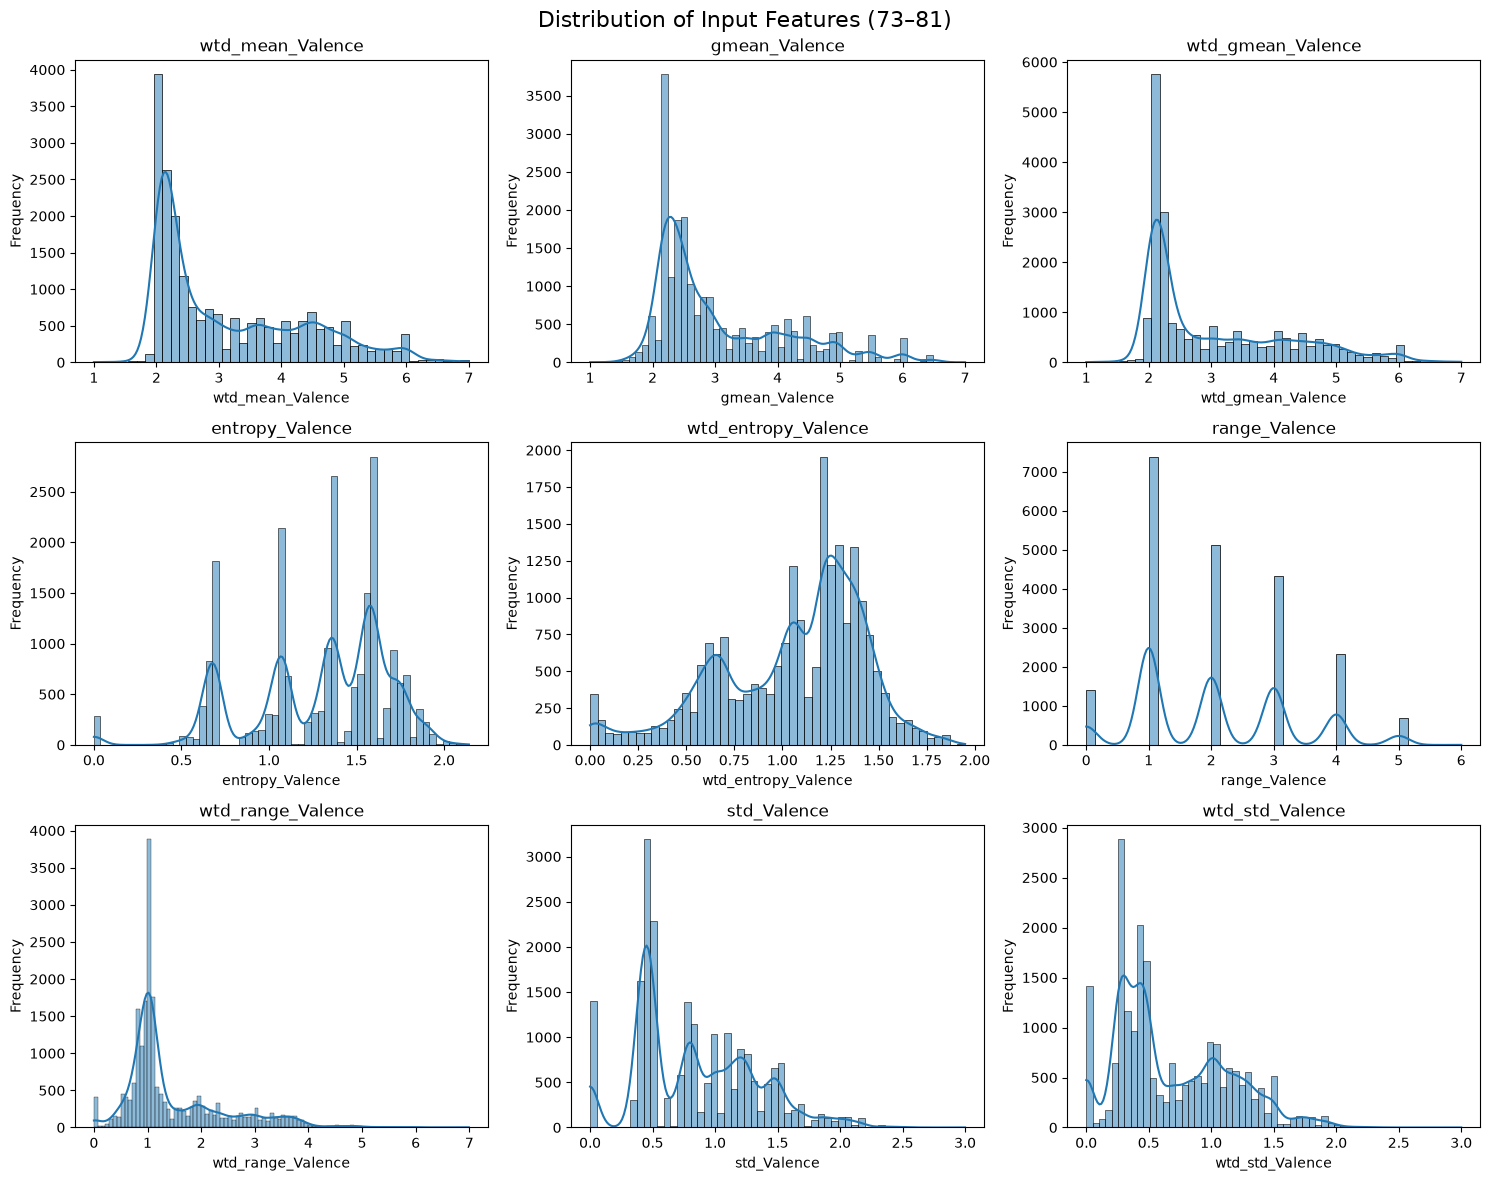

In [15]:
# Plot feature distributions in groups

features_per_plot = 12

for start in range(0, len(numerical_features), features_per_plot):
    
    feature_group = numerical_features[start:start + features_per_plot]
    
    n_features = len(feature_group)
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(15, 4 * n_rows)
    )
    
    axes = np.array(axes).reshape(-1)
    
    for i, feature in enumerate(feature_group):
        
        sns.histplot(
            df[feature],
            kde=True,
            ax=axes[i]
        )
        
        axes[i].set_title(feature)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")
    
    # Hide unused axes
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    fig.suptitle(
        f"Distribution of Input Features "
        f"({start + 1}–{start + n_features})",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()

### Inference

The feature distribution analysis shows that the Superconductivity dataset contains a large number of numerical features representing different material properties, including atomic mass, first ionization energy, atomic radius, density, electron affinity, fusion heat, thermal conductivity, and valence.

The distributions of these features are not identical, indicating differences in the scale and variability of the material properties. Some features may exhibit concentrated distributions, while others may show wider variation or skewness. These differences indicate that appropriate preprocessing, particularly feature scaling, will be important for scale-sensitive algorithms such as Ridge, Lasso, ElasticNet, SVR, and KNN.

The grouped visualization also makes it easier to compare related features within each material-property category while avoiding an overly crowded single figure. Further relationships between the features and the target variable will be examined using correlation analysis and feature-target plots.

### 6.2 Correlation Analysis

Correlation analysis is performed to understand the strength and direction of relationships between the numerical input features and the target variable `critical_temp`.

A correlation heatmap is used to identify:

- Strong positive and negative relationships between features
- Highly correlated feature pairs
- Features that show a meaningful relationship with `critical_temp`
- Possible multicollinearity among the input variables

Understanding these relationships will help guide feature engineering and model selection in the subsequent stages.

Top 5 positively correlated features:
 wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_entropy_atomic_mass        0.626930
Name: critical_temp, dtype: float64

Top 5 negatively correlated features:
 wtd_mean_Valence    -0.632401
wtd_gmean_Valence   -0.615653
mean_Valence        -0.600085
gmean_Valence       -0.573068
gmean_Density       -0.541684
Name: critical_temp, dtype: float64


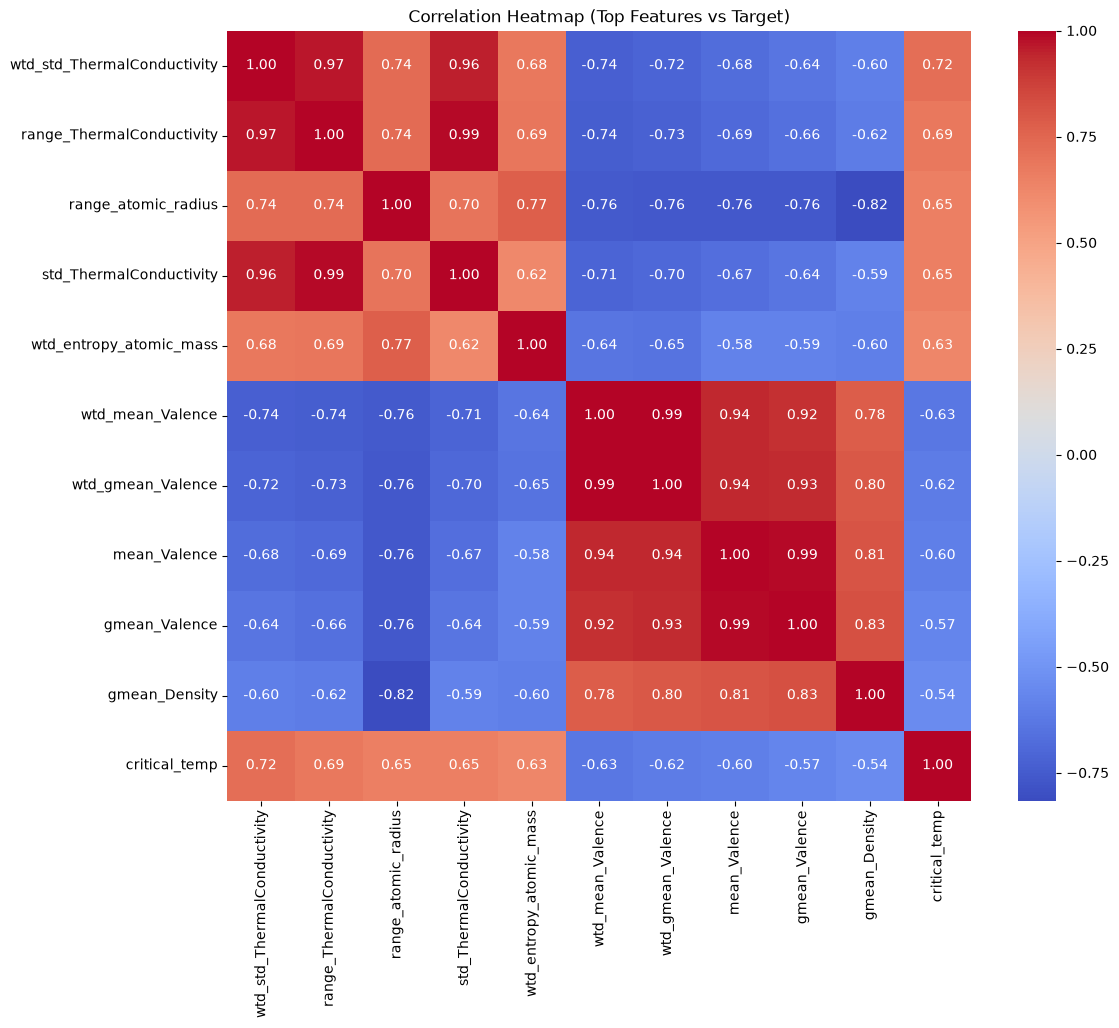

In [16]:
# Find top correlated features with target
correlations = df.corr()['critical_temp'].drop('critical_temp')
top_positive = correlations.sort_values(ascending=False).head(5)
top_negative = correlations.sort_values(ascending=True).head(5)

print("Top 5 positively correlated features:\n", top_positive)
print("\nTop 5 negatively correlated features:\n", top_negative)

# Heatmap of top features
top_features = top_positive.index.tolist() + top_negative.index.tolist() + ['critical_temp']
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top Features vs Target)')
plt.show()

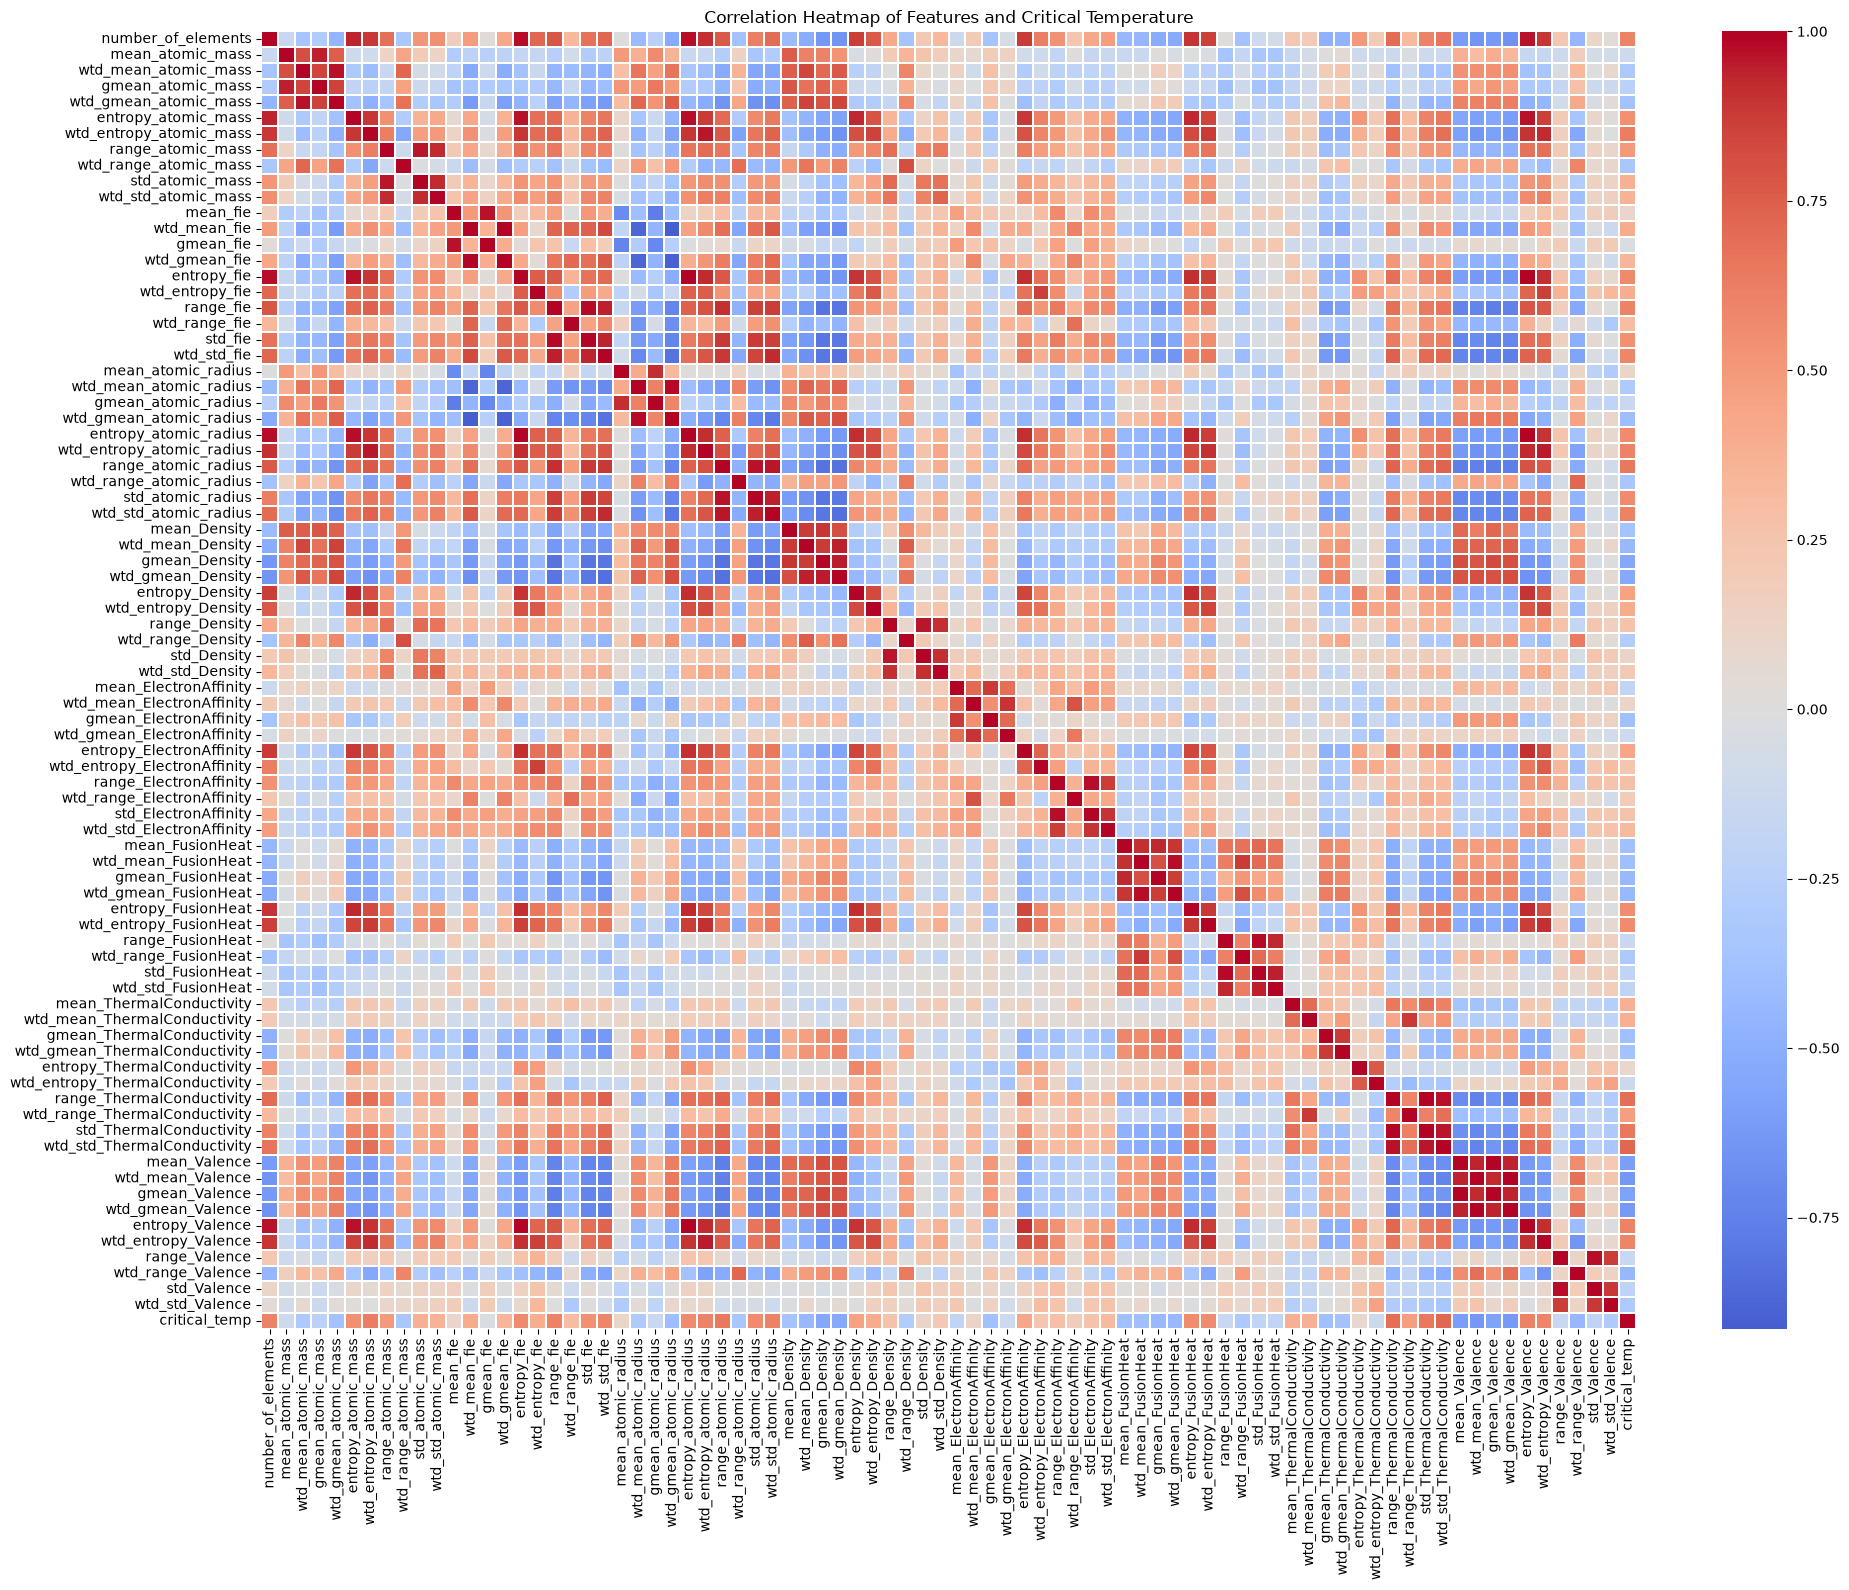

In [17]:
# Calculate correlation matrix
correlation_matrix = df[numerical_features + ["critical_temp"]].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap of Features and Critical Temperature")
plt.tight_layout()
plt.show()

### Inference

The correlation heatmap shows that several input features have noticeable correlations with one another, particularly among features belonging to the same material-property groups. This is expected because many of the features are different statistical representations of the same underlying material properties.

The heatmap also indicates that the relationship between individual features and the target variable `critical_temp` varies across the dataset, with some features showing stronger positive or negative correlations than others.

The presence of correlated input features suggests possible multicollinearity. Therefore, regularized regression techniques such as Ridge, Lasso, and ElasticNet will be useful during model development. The correlation analysis also provides guidance for identifying potentially informative features for predicting the critical temperature.

### 6.3 Feature–Target Relationship

To understand the relationship between the input features and the target variable `critical_temp`, scatter plots are used.

The features selected for visualization are based on their correlation with the target variable. This helps identify features that may have a stronger relationship with critical temperature and may therefore contribute to the predictive performance of the regression models.

In [18]:
# Calculate correlation of each feature with the target
target_correlations = (
    correlation_matrix["critical_temp"]
    .drop("critical_temp")
    .sort_values(key=abs, ascending=False)
)

# Display the top 10 features
print("Top 10 Features Correlated with Critical Temperature:")
display(target_correlations.head(10))

Top 10 Features Correlated with Critical Temperature:


wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_mean_Valence              -0.632401
wtd_entropy_atomic_mass        0.626930
wtd_gmean_Valence             -0.615653
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
Name: critical_temp, dtype: float64

To further understand the relationship between the input features and the target variable `critical_temp`, scatter plots are used for the features showing the strongest correlations with the target.

The selected features include both positively and negatively correlated variables. These plots help visually examine whether the relationships identified through correlation are also reflected in the distribution of individual observations.

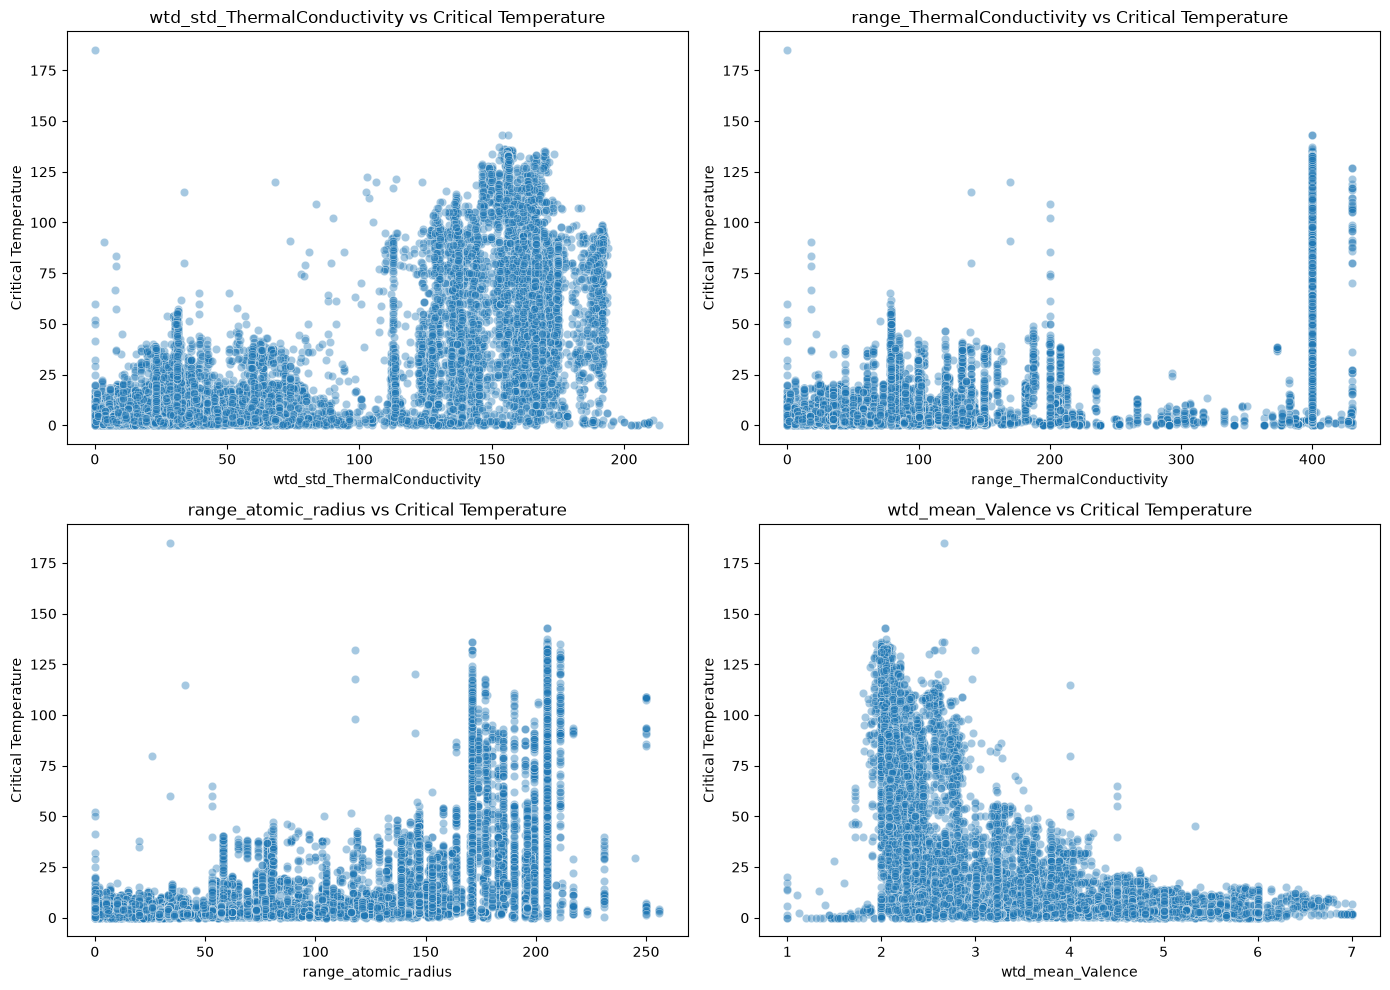

In [19]:
# Select four features with the strongest absolute correlation with the target
selected_features = [
    "wtd_std_ThermalConductivity",
    "range_ThermalConductivity",
    "range_atomic_radius",
    "wtd_mean_Valence"
]

# Create scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    
    sns.scatterplot(
        x=df[feature],
        y=df["critical_temp"],
        alpha=0.4,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature} vs Critical Temperature")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Critical Temperature")

plt.tight_layout()
plt.show()

### Inference

The scatter plots show that the selected features have noticeable relationships with `critical_temp`, which is consistent with the correlation analysis.

`wtd_std_ThermalConductivity`, `range_ThermalConductivity`, and `range_atomic_radius` show positive relationships with critical temperature, while `wtd_mean_Valence` shows a negative relationship.

However, the data points are widely scattered rather than forming a simple straight-line pattern. This indicates that the relationship between the material properties and critical temperature is complex and may involve nonlinear patterns.

Therefore, both linear and nonlinear regression algorithms will be evaluated in the later stages to determine which models are better suited for predicting `critical_temp`.

## 7. Data Preprocessing & Feature Engineering

Before training the regression models, the dataset must be prepared appropriately to ensure reliable and unbiased model evaluation.

The preprocessing stage includes:

1. Checking for constant and near-constant features
2. Checking and treating outliers
3. Handling duplicate observations
4. Defining input features and target variable
5. Feature engineering
6. Splitting the dataset into training and testing sets
7. Scaling the features where required

The preprocessing steps are performed carefully to avoid data leakage, particularly when calculating scaling parameters from the training data.

### 7.1 Checking Constant and Near-Constant Features

Constant and near-constant features are checked because features with little or no variation provide limited predictive information.

A constant feature has only one unique value across the dataset. Such features do not contribute to the prediction of `critical_temp` and can be removed if present.

In [20]:
# Check for constant features

constant_features = [
    col for col in numerical_features
    if df[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))

if len(constant_features) > 0:
    print("\nConstant features:")
    print(constant_features)
else:
    print("No constant features found.")

Number of constant features: 0
No constant features found.


In [21]:
# Check for near-constant features
# A feature is considered near-constant if one value occurs in more than 99% of rows.

near_constant_features = []

for col in numerical_features:
    value_frequency = df[col].value_counts(normalize=True).iloc[0]
    
    if value_frequency > 0.99:
        near_constant_features.append((col, value_frequency))

print("Number of near-constant features:", len(near_constant_features))

if len(near_constant_features) > 0:
    print("\nNear-constant features:")
    for feature, frequency in near_constant_features:
        print(f"{feature}: {frequency:.4%}")
else:
    print("No near-constant features found.")

Number of near-constant features: 0
No near-constant features found.


### Inference

The analysis shows that the dataset contains no constant or near-constant features. Therefore, all input features have sufficient variation across the observations and can be retained for further analysis and model development.

No feature removal is required at this stage based on feature variance.

### 7.2 Outlier Detection

Outliers are observations that differ substantially from the majority of the data. They are checked because extreme values can influence regression models and may affect model performance.

The Interquartile Range (IQR) method is used to identify potential outliers. For each numerical feature:

- Q1 represents the 25th percentile.
- Q3 represents the 75th percentile.
- IQR = Q3 − Q1.
- Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers.

The detected outliers will be evaluated before deciding whether treatment is necessary.

In [22]:
# Detect potential outliers using the IQR method

outlier_summary = []

for col in numerical_features:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) | 
        (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": col,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": (len(outliers) / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

# Display features with the highest number of potential outliers
outlier_df = outlier_df.sort_values(
    by="Outlier_Count",
    ascending=False
)

display(outlier_df)

,Feature,Outlier_Count,Outlier_Percentage
39,std_Density,3497,16.446409
46,wtd_entropy_ElectronAffinity,3428,16.121902
3,gmean_atomic_mass,3314,15.585759
37,range_Density,2908,13.676339
60,wtd_std_FusionHeat,2641,12.420637
...,...,...,...
67,range_ThermalConductivity,0,0.000000
69,std_ThermalConductivity,0,0.000000
70,wtd_std_ThermalConductivity,0,0.000000
76,wtd_entropy_Valence,0,0.000000


In [23]:
# Overall outlier summary

print("Total features analyzed:", len(numerical_features))
print(
    "Features containing potential outliers:",
    (outlier_df["Outlier_Count"] > 0).sum()
)

print(
    "Maximum outlier percentage in a single feature:",
    f"{outlier_df['Outlier_Percentage'].max():.2f}%"
)

Total features analyzed: 81
Features containing potential outliers: 63
Maximum outlier percentage in a single feature: 16.45%


### Inference

The IQR-based analysis identified potential outliers in 63 out of the 81 numerical features, with the maximum outlier proportion being 16.45% for `std_Density`.

The presence of potential outliers across multiple material-property features indicates that the dataset contains observations with values that differ substantially from the central distribution. However, these observations may represent genuine variations in the physical properties of superconducting materials rather than data-entry errors.

Therefore, the potential outliers will not be removed indiscriminately. The original observations will be retained, and the effect of extreme values will be handled through appropriate preprocessing and by evaluating models that are less sensitive to outliers.

### 7.3 Duplicate Treatment

Duplicate observations are checked to determine whether identical rows are present in the dataset. Exact duplicate rows do not provide additional information to the regression models and may introduce unnecessary repetition.

The duplicate analysis performed during the initial dataset inspection is used to determine the appropriate treatment.

In [24]:
# Check the number of exact duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:", 
      f"{(duplicate_count / len(df)) * 100:.2f}%")

Number of duplicate rows: 66
Percentage of duplicate rows: 0.31%


### Inference

The dataset contains 66 exact duplicate rows, representing only 0.31% of the total observations. Since these rows contain identical values across all features and the target variable, they do not provide additional information for model training.

Therefore, the exact duplicate rows will be removed before model development. This results in a cleaner dataset while retaining virtually all of the original observations.

In [25]:
# Remove exact duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (21197, 82)


### 7.4 Feature Engineering

Feature engineering is performed to create additional information from the existing material-property features.

Since thermal conductivity-related variables show a strong relationship with `critical_temp` in the correlation analysis, an additional feature based on these variables will be investigated.

The engineered feature should provide complementary information while avoiding data leakage and should be evaluated along with the original features during model development.

In [26]:
# Inspect the thermal conductivity features selected for feature engineering

thermal_features = [
    "wtd_std_ThermalConductivity",
    "range_ThermalConductivity"
]

display(df[thermal_features].describe())

,wtd_std_ThermalConductivity,range_ThermalConductivity
count,21197.000000,21197.000000
mean,96.419168,251.401535
std,63.694958,158.612185
min,0.000000,0.000000
25%,31.999086,87.000000
50%,115.035273,399.973420
75%,162.810294,399.973420
max,213.300452,429.974170




Based on the correlation analysis, thermal-conductivity-related features show strong relationships with the target variable `critical_temp`.

Two such features, `wtd_std_ThermalConductivity` and `range_ThermalConductivity`, describe the variability and range of thermal conductivity in the material composition.

An engineered feature named `thermal_conductivity_variability` will be created by combining the scaled versions of these two features. Combining related standardized measurements provides a single feature representing overall thermal-conductivity variability.

The scaling parameters used to construct this feature will be learned only from the training data to prevent data leakage.

### 7.5 Train/Test Split

The dataset is divided into training and testing sets before model training.

The training set is used to train the regression models and learn preprocessing parameters, while the testing set is kept separate for final model evaluation.

A fixed `random_state` of 42 is used to ensure reproducibility. The same test set will be used for all ten regression algorithms so that their performance can be compared fairly.

In [27]:
# Define input features and target variable

X = df.drop(columns=["critical_temp"])
y = df["critical_temp"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (21197, 81)
Target shape: (21197,)


In [28]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (16957, 81)
Testing set shape: (4240, 81)
Training target shape: (16957,)
Testing target shape: (4240,)


### Inference

The dataset was divided into 16,957 training samples and 4,240 testing samples using an 80:20 split.

The training set will be used for model training and for learning preprocessing parameters, while the testing set will remain completely separate for final model evaluation.

The same training and testing sets will be used for all ten regression algorithms to ensure a fair comparison of model performance. A fixed `random_state` of 42 ensures that the split is reproducible.

### 7.6 Feature Engineering and Scaling

Based on the EDA, thermal-conductivity-related features showed strong relationships with the target variable `critical_temp`.

The features `wtd_std_ThermalConductivity` and `range_ThermalConductivity` are selected to construct an engineered feature called `thermal_conductivity_variability`.

Since these two features have different scales, they are first standardized using `StandardScaler`. The scaler is fitted only on the training data and then applied to the testing data to prevent data leakage.

The standardized values of the two features are then combined to represent the overall variability of thermal conductivity.

In [29]:
from sklearn.preprocessing import StandardScaler

# Features selected for engineering
thermal_features = [
    "wtd_std_ThermalConductivity",
    "range_ThermalConductivity"
]

# Create a scaler for the selected thermal features
thermal_scaler = StandardScaler()

# Fit only on training data
thermal_train = thermal_scaler.fit_transform(
    X_train[thermal_features]
)

# Transform test data using the same scaler
thermal_test = thermal_scaler.transform(
    X_test[thermal_features]
)

# Create copies before adding the engineered feature
X_train = X_train.copy()
X_test = X_test.copy()

# Create engineered feature
X_train["thermal_conductivity_variability"] = thermal_train.sum(axis=1)
X_test["thermal_conductivity_variability"] = thermal_test.sum(axis=1)

print("Training set shape after feature engineering:", X_train.shape)
print("Testing set shape after feature engineering:", X_test.shape)
print("\nEngineered feature added: thermal_conductivity_variability")

Training set shape after feature engineering: (16957, 82)
Testing set shape after feature engineering: (4240, 82)

Engineered feature added: thermal_conductivity_variability


### 7.7 Preprocessing Verification

The preprocessing steps are verified before proceeding to model training.

The verification checks:

1. The training and testing datasets have the expected dimensions.
2. No missing values are present after preprocessing.
3. The engineered feature is present in both datasets.
4. The training and testing feature columns are identical and in the same order.

These checks ensure that the datasets are correctly prepared for training and evaluation of the regression models.

In [30]:
# Verify dataset dimensions
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Check missing values
print("\nMissing values in training set:", X_train.isnull().sum().sum())
print("Missing values in testing set:", X_test.isnull().sum().sum())

# Check engineered feature
print(
    "\nEngineered feature present in training set:",
    "thermal_conductivity_variability" in X_train.columns
)

print(
    "Engineered feature present in testing set:",
    "thermal_conductivity_variability" in X_test.columns
)

# Check whether feature columns match
print(
    "\nTraining and testing feature columns match:",
    list(X_train.columns) == list(X_test.columns)
)

Training set shape: (16957, 82)
Testing set shape: (4240, 82)

Missing values in training set: 0
Missing values in testing set: 0

Engineered feature present in training set: True
Engineered feature present in testing set: True

Training and testing feature columns match: True


### Inference

The preprocessing verification confirms that the training and testing datasets are correctly prepared for model development.

Both datasets contain the expected 82 features, including the engineered `thermal_conductivity_variability` feature. No missing values are present, and the feature columns are identical and in the same order.

The preprocessing pipeline also maintains separation between training and testing data, ensuring that the testing set remains unseen during model preparation.

The dataset is therefore ready for regression model training and evaluation.

## 8. Regression Model Development

The prepared dataset is now used to develop and evaluate regression models for predicting the critical temperature (`critical_temp`) of superconducting materials.

Ten regression algorithms specified in the project guidelines will be implemented. All models will use the same training and testing datasets, and their performance will be evaluated using R², RMSE, and MAE.

The models will be compared using the same evaluation procedure to ensure a fair and consistent comparison.

### 8.1 Regression Evaluation Setup

The following evaluation metrics will be used:

- **R² (Coefficient of Determination):** Measures how much of the variation in the target variable is explained by the model. Higher values indicate better performance.
- **RMSE (Root Mean Squared Error):** Measures the average magnitude of prediction errors while giving greater weight to larger errors. Lower values are better.
- **MAE (Mean Absolute Error):** Measures the average absolute prediction error. Lower values are better.

R² will be used as the primary metric for ranking the regression models, while RMSE and MAE will provide additional information about prediction error.

In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Container for storing regression results
regression_results = []

print("Regression evaluation setup completed.")
print("Primary metric: R²")
print("Additional metrics: RMSE and MAE")

Regression evaluation setup completed.
Primary metric: R²
Additional metrics: RMSE and MAE


### 8.2 Linear Regression

Linear Regression is used as the baseline regression model. It assumes a linear relationship between the input features and the target variable `critical_temp`.

Since the dataset contains features with different numerical scales, feature standardization is applied before training. The scaler is fitted only on the training data to avoid data leakage.

The trained model is evaluated on the same held-out test set using R², RMSE, and MAE.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled_lr, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled_lr)

# Evaluation metrics
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)

# Store results
regression_results.append({
    "Model": "Linear Regression",
    "R²": lr_r2,
    "RMSE": lr_rmse,
    "MAE": lr_mae
})

print("Linear Regression completed.")

Linear Regression completed.


### 8.3 Ridge Regression

Ridge Regression is a regularized form of linear regression that adds an L2 penalty to the model coefficients.

Regularization helps reduce the effect of multicollinearity and can improve generalization when the dataset contains correlated features.

A baseline Ridge Regression model is first trained using the standardized training data. Hyperparameter tuning of the `alpha` parameter will be performed later using GridSearchCV.

In [33]:
from sklearn.linear_model import Ridge

# Create and train baseline Ridge Regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled_lr, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test_scaled_lr)

# Calculate evaluation metrics
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

# Store results
regression_results.append({
    "Model": "Ridge Regression",
    "R²": ridge_r2,
    "RMSE": ridge_rmse,
    "MAE": ridge_mae
})

print("Ridge Regression completed.")

Ridge Regression completed.


### 8.4 Lasso Regression

Lasso Regression is a regularized linear regression technique that applies an L1 penalty to the model coefficients.

Unlike Ridge Regression, Lasso can shrink some coefficients completely to zero. This property can produce a sparser model and may help identify less important features.

A baseline Lasso model is trained using the standardized training data. Hyperparameter tuning can be performed later if required.

In [34]:
from sklearn.linear_model import Lasso

# Create and train baseline Lasso Regression model
lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train_scaled_lr, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test_scaled_lr)

# Calculate evaluation metrics
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

# Store results
regression_results.append({
    "Model": "Lasso Regression",
    "R²": lasso_r2,
    "RMSE": lasso_rmse,
    "MAE": lasso_mae
})

print("Lasso Regression completed.")

Lasso Regression completed.


### 8.5 ElasticNet Regression

ElasticNet Regression combines the properties of Lasso and Ridge Regression by applying both L1 and L2 regularization.

The `l1_ratio` parameter controls the balance between the L1 and L2 penalties. A value closer to 1 gives more importance to Lasso-type regularization, while a value closer to 0 gives more importance to Ridge-type regularization.

A baseline ElasticNet model is trained using the standardized training data. Hyperparameter tuning of `l1_ratio` will be considered during the model tuning stage.

In [35]:
from sklearn.linear_model import ElasticNet

# Create and train baseline ElasticNet model
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_scaled_lr, y_train)

# Make predictions
y_pred_elastic = elastic_model.predict(X_test_scaled_lr)

# Calculate evaluation metrics
elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

# Store results
regression_results.append({
    "Model": "ElasticNet",
    "R²": elastic_r2,
    "RMSE": elastic_rmse,
    "MAE": elastic_mae
})

print("ElasticNet Regression completed.")

ElasticNet Regression completed.


### 8.6 Polynomial Regression

Polynomial Regression extends Linear Regression by introducing polynomial terms to capture nonlinear relationships between the input features and the target variable.

Since the dataset contains 82 features after feature engineering, applying polynomial expansion to all features would produce a very large number of derived features. Therefore, the polynomial model is applied to selected informative features identified during the EDA stage.

Different polynomial degrees will be compared to determine whether increasing model complexity improves prediction performance.